In [3]:
!pip install pandas matplotlib

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [5]:
print("="*50)
print("AI CAREER RECOMMENDATION ASSISTANT")
print("="*50)

name = input("Enter your name: ")

print("\nRate your interests from 1-10")

AI CAREER RECOMMENDATION ASSISTANT


Enter your name:  Dhruv



Rate your interests from 1-10


In [6]:
coding = int(input("Coding: "))
ai = int(input("Artificial Intelligence: "))
design = int(input("Design: "))
business = int(input("Business: "))


Coding:  8
Artificial Intelligence:  7
Design:  8
Business:  5


In [7]:
print("\nPersonality Questions")


Personality Questions


In [8]:
analytical = input("Do you enjoy solving logical problems? (y/n): ")
leadership = input("Do you enjoy leading teams? (y/n): ")
creativity = input("Do you enjoy creative work? (y/n): ")

Do you enjoy solving logical problems? (y/n):  y
Do you enjoy leading teams? (y/n):  y
Do you enjoy creative work? (y/n):  y


In [9]:
analytical_score = 10 if analytical.lower() == "y" else 0
leadership_score = 10 if leadership.lower() == "y" else 0
creativity_score = 10 if creativity.lower() == "y" else 0

In [10]:
df = pd.read_csv("careers.csv")



TOP CAREER RECOMMENDATIONS
1. Machine Learning Engineer (100.0%)
2. Product Manager (91.74%)
3. Data Scientist (90.6%)
4. AI Researcher (84.05%)
5. Business Analyst (79.49%)


WHY THIS CAREER?
Strong coding + AI interest + analytical thinking.


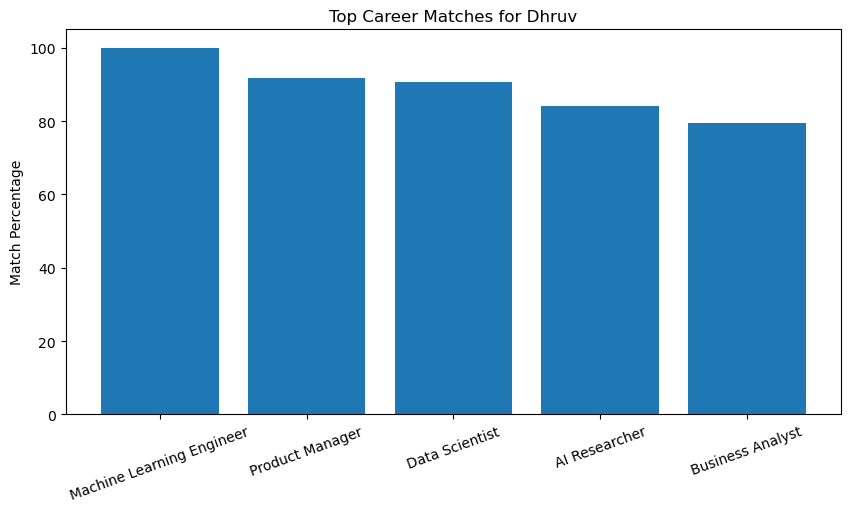


History Saved Successfully


In [11]:
scores = []

for _, row in df.iterrows():

    score = 0

    score += (coding * row["Coding"])
    score += (ai * row["AI"])
    score += (design * row["Design"])
    score += (business * row["Business"])

    score += (analytical_score * row["Analytical"])
    score += (leadership_score * row["Leadership"])
    score += (creativity_score * row["Creativity"])

    scores.append(score)

df["MatchScore"] = scores

max_score = df["MatchScore"].max()

df["MatchPercent"] = round(
    (df["MatchScore"] / max_score) * 100,
    2
)

recommendations = df.sort_values(
    by="MatchPercent",
    ascending=False
)

print("\n")
print("="*50)
print("TOP CAREER RECOMMENDATIONS")
print("="*50)

top5 = recommendations.head(5)

for i, row in enumerate(top5.itertuples(), start=1):

    print(
        f"{i}. {row.Career} "
        f"({row.MatchPercent}%)"
    )

best = top5.iloc[0]

print("\n")
print("="*50)
print("WHY THIS CAREER?")
print("="*50)

if best["Career"] == "Machine Learning Engineer":
    print("Strong coding + AI interest + analytical thinking.")

elif best["Career"] == "Data Scientist":
    print("Excellent data reasoning and AI inclination.")

elif best["Career"] == "Software Engineer":
    print("High coding ability and problem-solving mindset.")

elif best["Career"] == "UI UX Designer":
    print("Strong creativity and design orientation.")

elif best["Career"] == "Product Manager":
    print("Leadership and business-focused profile.")

else:
    print("Balanced profile suitable for this role.")

history = pd.DataFrame({
    "Name":[name],
    "Date":[datetime.now()],
    "TopCareer":[best["Career"]],
    "MatchPercent":[best["MatchPercent"]]
})

history.to_csv(
    "user_history.csv",
    mode="a",
    header=False,
    index=False
)

plt.figure(figsize=(10,5))

plt.bar(
    top5["Career"],
    top5["MatchPercent"]
)

plt.xticks(rotation=20)

plt.ylabel("Match Percentage")

plt.title(
    f"Top Career Matches for {name}"
)

plt.show()

print("\nHistory Saved Successfully")